In [39]:
import pandas as pd
import numpy as np
from utils import plot
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf
from arch.unitroot import VarianceRatio

In [40]:
def get_slope(x,h):
    slope_2 = []
    partial_array_2 = np.zeros(h)
    n = len(x)

    for step in range(n):
        old_x = partial_array_2[step % h]
        partial_array_2[step % h] = x[step]

        m = min(step + 1, h)

        if m == 1:
            sum_1 = x[step]
            sum_2 = x[step]
            a2 = 0
            is_first_time = True
        else:
            if m < h:
                sum_1 = sum_1 + m*x[step]
                sum_2 = sum_2 + x[step]
            else:
                if is_first_time:
                    sum_1 = sum_1 + m*x[step]
                    sum_2 = sum_2 + x[step]
                    is_first_time = False
                else:
                    sum_1 = sum_1 - sum_2 + m*x[step]
                    sum_2 = sum_2 - old_x + x[step]
                
            mu = (m + 1)/2
            denom = m*(m**2 - 1)/12

            a2 = (sum_1 - mu*sum_2)/denom
        
            #print(sum_1 - mu*sum_2, denom)
        slope_2.append(a2)

    return slope_2

In [41]:
df = pd.read_csv('wbtc_train_data_expanded.csv')

nav = df['nav'].values
nect_price = df['nect_price'].values
vol_token_price = df['wbtc_price'].values
volatile_part = df['wbtc_frac'].values
timestamps = df['timestamp'].values

nav = nav[::4]
nect_price = nect_price[::4]
vol_token_price = vol_token_price[::4]
volatile_part = volatile_part[12000::4]

c:\Proga\leverege_simul\for_server\model_train\statistic\utils.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


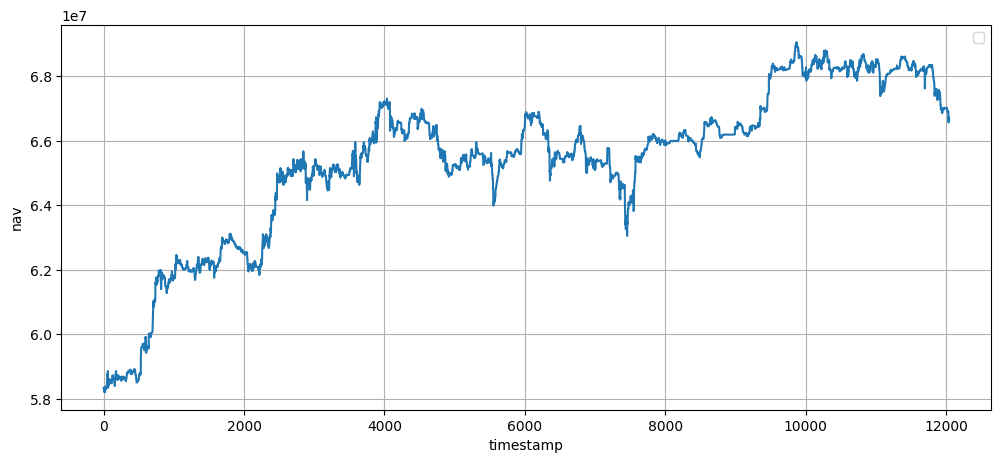

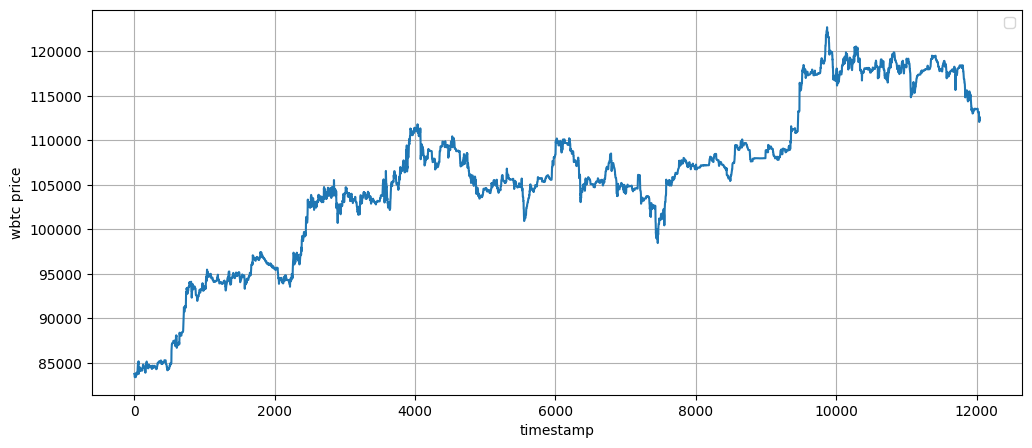

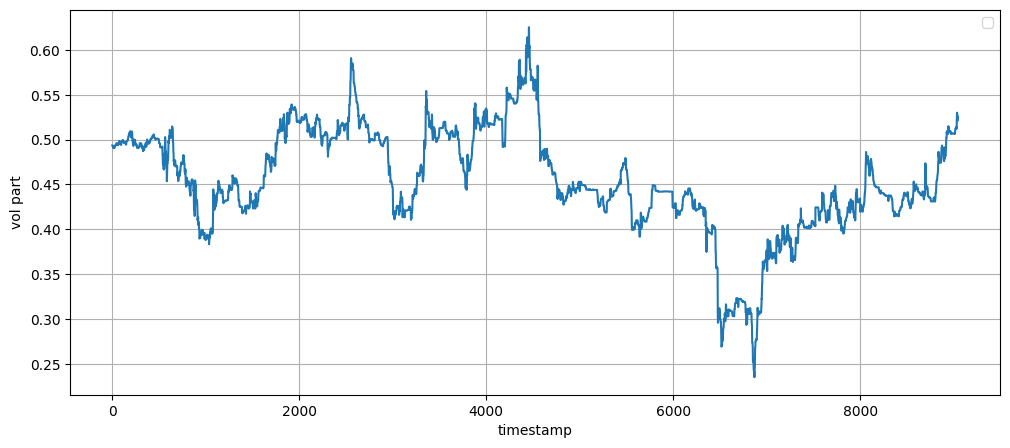

In [42]:
plot(
    series = [nav],
    x = 'timestamp',
    y = 'nav'
)

plot(
    series = [vol_token_price],
    x = 'timestamp',
    y = 'wbtc price'
)

plot(
    series = [volatile_part],
    x = 'timestamp',
    y = 'vol part'
)

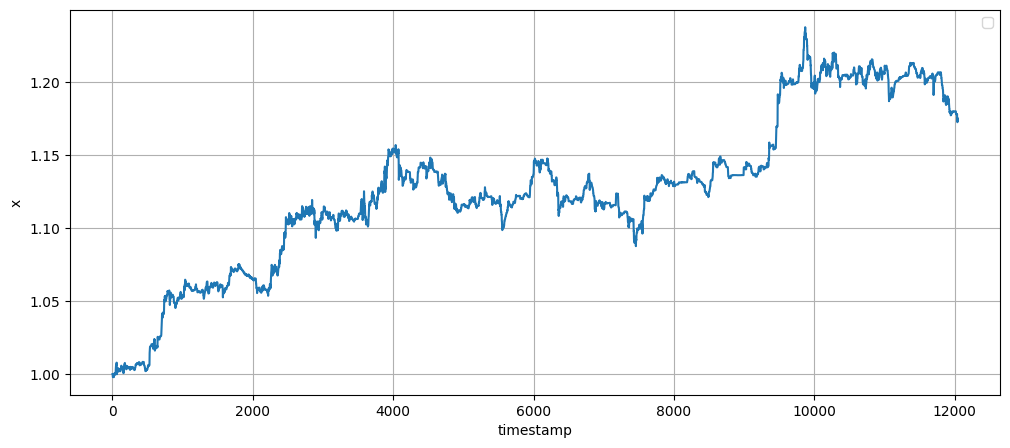

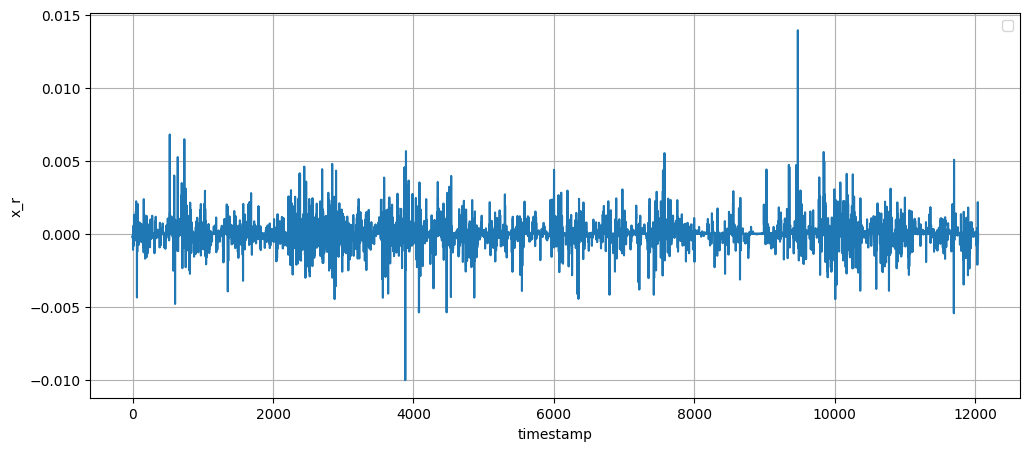

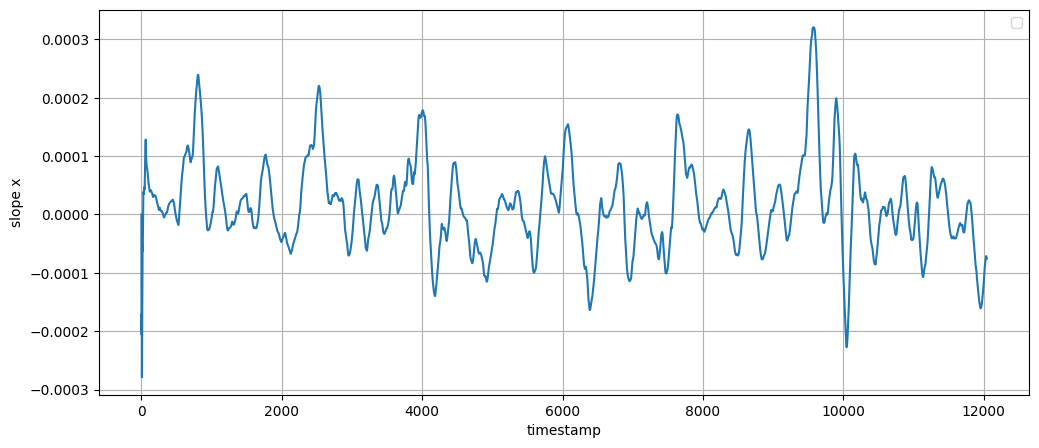

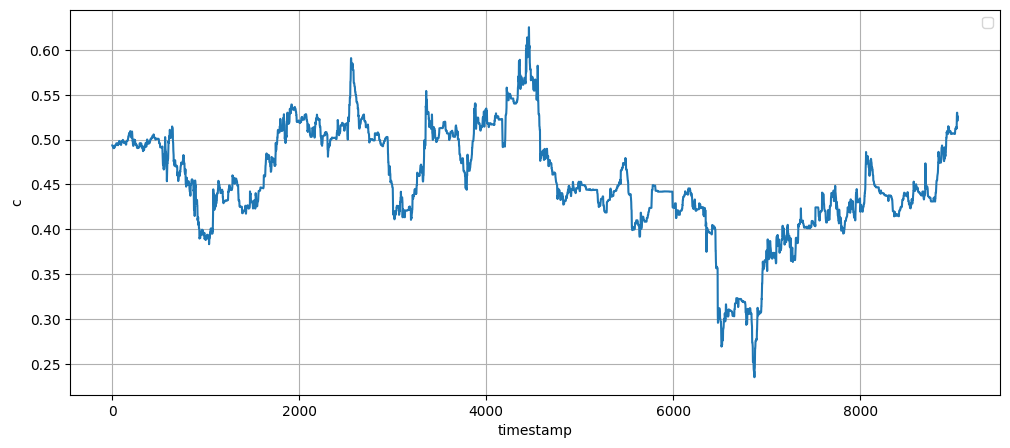

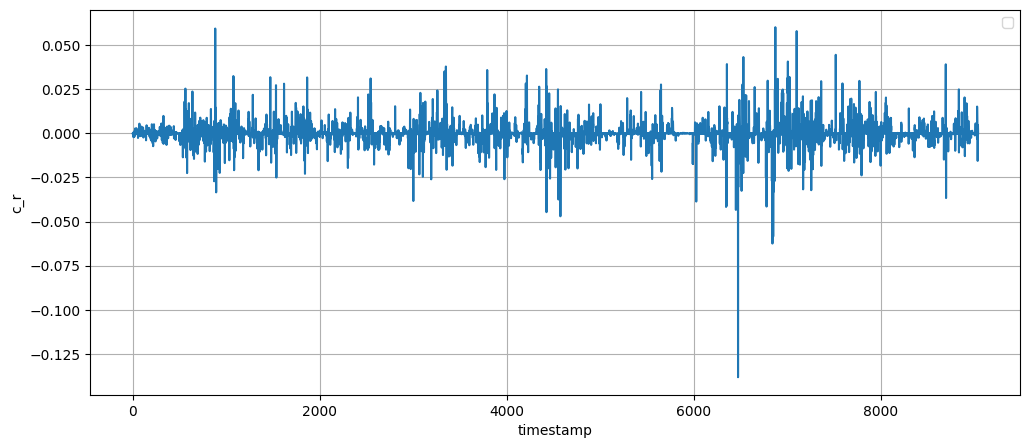

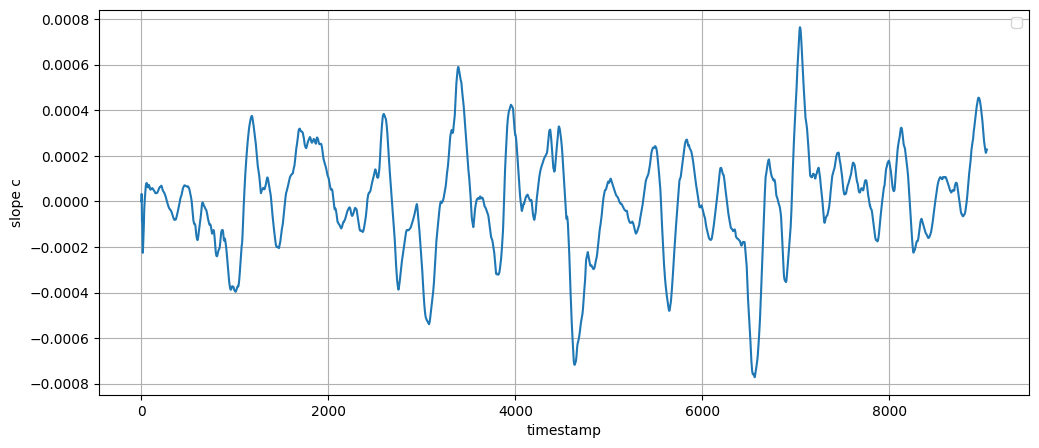

In [43]:
x = vol_token_price/nav*nav[0]/vol_token_price[0]
c = volatile_part
c_r = np.diff(np.log(c))
x_r = np.diff(np.log(x))
x_slope = get_slope(x, 200)
c_slope = get_slope(c, 200)

plot(
    series = [x],
    x = 'timestamp',
    y = 'x'
)

plot(
    series = [x_r],
    x = 'timestamp',
    y = 'x_r'
)

plot(
    series = [x_slope],
    x = 'timestamp',
    y = 'slope x'
)

plot(
    series = [c],
    x = 'timestamp',
    y = 'c'
)

plot(
    series = [c_r],
    x = 'timestamp',
    y = 'c_r'
)

plot(
    series = [c_slope],
    x = 'timestamp',
    y = 'slope c'
)

In [44]:
def memory_diagnostics(x, lags=40, alpha=0.05, verbose=True):
    x = np.asarray(x).astype(float)
    x = x[np.isfinite(x)]
    n = len(x)

    plot_acf(x, lags=lags)

    # Stationarity
    adf_stat, adf_p, *_ = adfuller(x, autolag='AIC')
    try:
        kpss_stat, kpss_p, *_ = kpss(x, regression='c', nlags='auto')
    except:
        kpss_p = np.nan  # fallback if KPSS fails (short data)

    # Autocorrelation (Ljung–Box)
    lb_df = acorr_ljungbox(x, lags=[lags], return_df=True)
    lb_p = lb_df['lb_pvalue'].iloc[0]

    # Volatility clustering (ARCH LM)
    arch_stat, arch_p, *_ = het_arch(x, maxlag=lags)

    # Nonlinearity (Variance Ratio test as proxy)
    try:
        vr_p = VarianceRatio(x).pvalue
    except:
        vr_p = np.nan

    # Simple predictability (AR(1))
    try:
        ar1_fit = AutoReg(x, lags=1).fit()
        ar1_r2 = ar1_fit.rsquared
    except:
        ar1_r2 = np.nan

    # Summary
    results = {
        'n_obs': n,
        'ADF_p': adf_p,
        'KPSS_p': kpss_p,
        'LjungBox_p': lb_p,
        'ARCH_p': arch_p,
        'VR_p': vr_p,
        'AR1_R2': ar1_r2
    }

    if verbose:
        print("=== MEMORY DIAGNOSTICS ===")
        print(f"n = {n}")
        print(f"ADF p = {adf_p:.3g}  → {'stationary ✅' if adf_p < alpha else 'non-stationary ❌'}")
        print(f"KPSS p = {kpss_p:.3g}  → {'stationary ✅' if kpss_p > alpha else 'non-stationary ❌'}")
        print(f"Ljung–Box (lag {lags}) p = {lb_p:.3g}  → {'autocorrelated ✅' if lb_p < alpha else 'independent ❌'}")
        print(f"ARCH LM p = {arch_p:.3g}  → {'volatility memory ✅' if arch_p < alpha else 'no volatility memory ❌'}")
        print(f"Variance Ratio p = {vr_p:.3g}  → {'nonlinear dep. ✅' if vr_p < alpha else 'no nonlinearity ❌'}")
        print(f"AR(1) R² = {ar1_r2:.3f}  → {'some predictability ✅' if ar1_r2 > 0.01 else 'little predictability ❌'}")
        print("===========================")

    return results

=== MEMORY DIAGNOSTICS ===
n = 9045
ADF p = 0.189  → non-stationary ❌
KPSS p = 0.01  → non-stationary ❌
Ljung–Box (lag 40) p = 0  → autocorrelated ✅
ARCH LM p = 0  → volatility memory ✅
Variance Ratio p = 0  → nonlinear dep. ✅
AR(1) R² = nan  → little predictability ❌


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15100\2038899859.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression='c', nlags='auto')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15100\2038899859.py:20: FutureWarning: the 'maxlag' keyword is deprecated, use 'nlags' instead.
  arch_stat, arch_p, *_ = het_arch(x, maxlag=lags)


{'n_obs': 9045,
 'ADF_p': np.float64(0.1887511325435161),
 'KPSS_p': np.float64(0.01),
 'LjungBox_p': np.float64(0.0),
 'ARCH_p': np.float64(0.0),
 'VR_p': np.float64(0.0),
 'AR1_R2': nan}

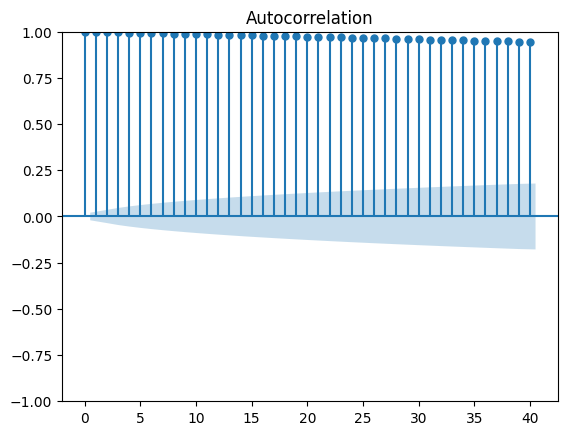

In [45]:
memory_diagnostics(c)

=== MEMORY DIAGNOSTICS ===
n = 9044
ADF p = 0  → stationary ✅
KPSS p = 0.1  → stationary ✅
Ljung–Box (lag 40) p = 6.4e-133  → autocorrelated ✅
ARCH LM p = 6.36e-20  → volatility memory ✅
Variance Ratio p = 9.23e-13  → nonlinear dep. ✅
AR(1) R² = nan  → little predictability ❌


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15100\2038899859.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression='c', nlags='auto')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15100\2038899859.py:20: FutureWarning: the 'maxlag' keyword is deprecated, use 'nlags' instead.
  arch_stat, arch_p, *_ = het_arch(x, maxlag=lags)


{'n_obs': 9044,
 'ADF_p': 0.0,
 'KPSS_p': np.float64(0.1),
 'LjungBox_p': np.float64(6.398069871758332e-133),
 'ARCH_p': np.float64(6.363111047332891e-20),
 'VR_p': np.float64(9.228173780684301e-13),
 'AR1_R2': nan}

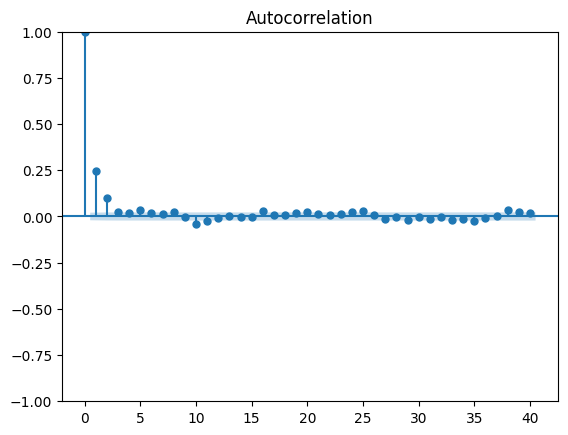

In [46]:
memory_diagnostics(c_r)

=== MEMORY DIAGNOSTICS ===
n = 9045
ADF p = 4.17e-12  → stationary ✅
KPSS p = 0.1  → stationary ✅
Ljung–Box (lag 40) p = 0  → autocorrelated ✅
ARCH LM p = 0  → volatility memory ✅
Variance Ratio p = 0  → nonlinear dep. ✅
AR(1) R² = nan  → little predictability ❌


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15100\2038899859.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression='c', nlags='auto')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15100\2038899859.py:20: FutureWarning: the 'maxlag' keyword is deprecated, use 'nlags' instead.
  arch_stat, arch_p, *_ = het_arch(x, maxlag=lags)


{'n_obs': 9045,
 'ADF_p': np.float64(4.165412546927344e-12),
 'KPSS_p': np.float64(0.1),
 'LjungBox_p': np.float64(0.0),
 'ARCH_p': np.float64(0.0),
 'VR_p': np.float64(0.0),
 'AR1_R2': nan}

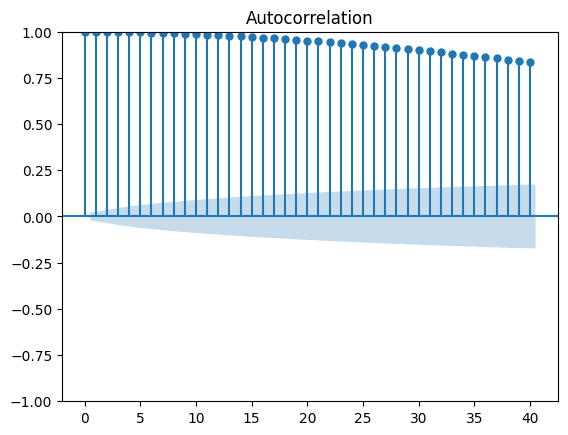

In [47]:
memory_diagnostics(c_slope)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15100\2038899859.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression='c', nlags='auto')


=== MEMORY DIAGNOSTICS ===
n = 12045
ADF p = 0.191  → non-stationary ❌
KPSS p = 0.01  → non-stationary ❌
Ljung–Box (lag 40) p = 0  → autocorrelated ✅
ARCH LM p = 0  → volatility memory ✅
Variance Ratio p = 0  → nonlinear dep. ✅
AR(1) R² = nan  → little predictability ❌


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15100\2038899859.py:20: FutureWarning: the 'maxlag' keyword is deprecated, use 'nlags' instead.
  arch_stat, arch_p, *_ = het_arch(x, maxlag=lags)


{'n_obs': 12045,
 'ADF_p': np.float64(0.19070840191810023),
 'KPSS_p': np.float64(0.01),
 'LjungBox_p': np.float64(0.0),
 'ARCH_p': np.float64(0.0),
 'VR_p': np.float64(0.0),
 'AR1_R2': nan}

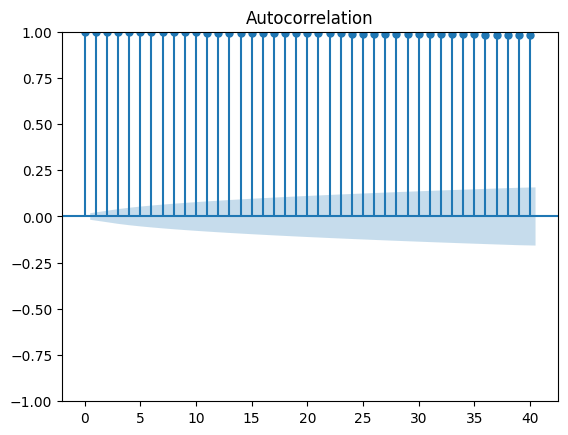

In [48]:
memory_diagnostics(x)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15100\2038899859.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression='c', nlags='auto')


=== MEMORY DIAGNOSTICS ===
n = 12044
ADF p = 0  → stationary ✅
KPSS p = 0.1  → stationary ✅
Ljung–Box (lag 40) p = 3.14e-132  → autocorrelated ✅
ARCH LM p = 3.08e-31  → volatility memory ✅
Variance Ratio p = 0  → nonlinear dep. ✅
AR(1) R² = nan  → little predictability ❌


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15100\2038899859.py:20: FutureWarning: the 'maxlag' keyword is deprecated, use 'nlags' instead.
  arch_stat, arch_p, *_ = het_arch(x, maxlag=lags)


{'n_obs': 12044,
 'ADF_p': 0.0,
 'KPSS_p': np.float64(0.1),
 'LjungBox_p': np.float64(3.141312909765897e-132),
 'ARCH_p': np.float64(3.07764182116539e-31),
 'VR_p': np.float64(0.0),
 'AR1_R2': nan}

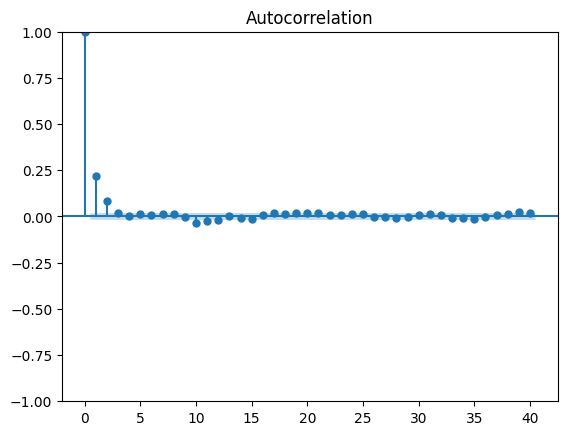

In [49]:
memory_diagnostics(x_r)

=== MEMORY DIAGNOSTICS ===
n = 12045
ADF p = 1.68e-12  → stationary ✅
KPSS p = 0.0768  → stationary ✅
Ljung–Box (lag 40) p = 0  → autocorrelated ✅
ARCH LM p = 0  → volatility memory ✅
Variance Ratio p = 0.665  → no nonlinearity ❌
AR(1) R² = nan  → little predictability ❌


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15100\2038899859.py:20: FutureWarning: the 'maxlag' keyword is deprecated, use 'nlags' instead.
  arch_stat, arch_p, *_ = het_arch(x, maxlag=lags)


{'n_obs': 12045,
 'ADF_p': np.float64(1.6806831233576057e-12),
 'KPSS_p': np.float64(0.07679455328455037),
 'LjungBox_p': np.float64(0.0),
 'ARCH_p': np.float64(0.0),
 'VR_p': np.float64(0.6651599823342798),
 'AR1_R2': nan}

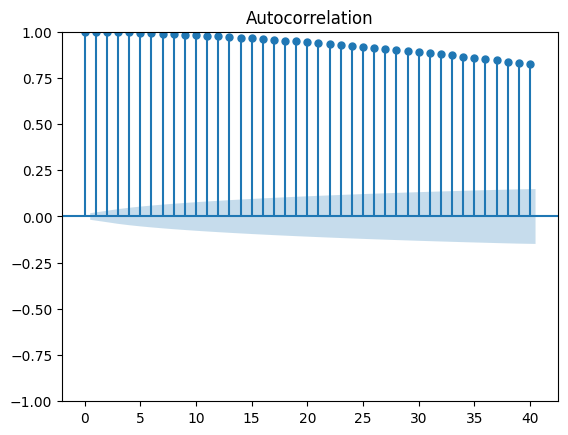

In [50]:
memory_diagnostics(x_slope)